In [124]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import torch
import pandas as pd
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
from tqdm import tqdm
from fastprogress import master_bar, progress_bar
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
import seaborn as sns
import xgboost as xgb

import torchsummary


torch.manual_seed(42) # Set manual seed

In [5]:
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cuda:0


In [6]:
#Import data and preprocessing

train_data = pd.read_csv("train_listings.csv")[["latitude", "longitude", "price"]]
test_data = pd.read_csv("test_listings.csv")[["latitude", "longitude", "price"]]
train_data["price"] = pd.to_numeric(train_data["price"].replace('[\$,]', '', regex=True))  ## get rid of $ sign
test_data["price"] = pd.to_numeric(test_data["price"].replace('[\$,]', '', regex=True))
train_data = train_data.values
test_data = test_data.values

data_len = len(train_data)
val_len = int(0.1 * data_len)
train_len = data_len - val_len
train_subset, val_subset = random_split(train_data, [train_len, val_len])

X_train = np.array([[train_subset[i][0], train_subset[i][1]] for i in range(len(train_subset))])
y_train = np.array([train_subset[i][2] for i in range(len(train_subset))])
X_val = np.array([[val_subset[i][0], val_subset[i][1]] for i in range(len(val_subset))])
y_val = np.array([val_subset[i][2] for i in range(len(val_subset))])
X_test = np.array([[test_data[i, 0], test_data[i, 1]] for i in range(len(test_data))])
y_test = test_data[:, 2]

In [25]:
pd.read_csv("train_listings.csv")["neighbourhood"]

,neighbourhood
0,"Amsterdam, North Holland, Netherlands"
1,NaN
2,"Amsterdam, Noord-Holland, Netherlands"
3,"Amsterdam, Noord-Holland, Netherlands"
4,NaN
...,...
5051,"Amsterdam, Noord-Holland, Netherlands"
5052,NaN
5053,NaN
5054,"Amsterdam, North Holland, Netherlands"


In [10]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42, ## random seed
    tree_method="hist",
    device="cuda:0",
    booster="gbtree"
)

In [11]:
model.fit(X_train, y_train)

# --- Evaluation ---
y_pred = model.predict(X_val)

In [12]:
rmse = mean_squared_error(y_val, y_pred)
r2score = r2_score(y_val, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 score: {r2score:.2f}")

Root Mean Squared Error: 202856.41
R2 score: 0.99


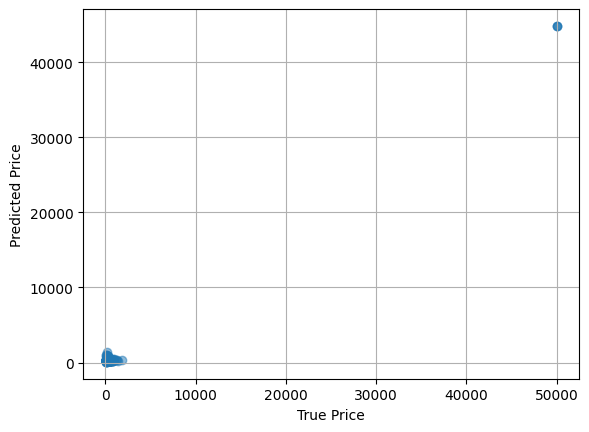

In [13]:
plt.scatter(y_val, y_pred, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

The plot indicates that there are outliers in the data

In [14]:
len(y_train) - len(y_train[y_train < 9000]), len(y_train) - len(y_train[y_train < 1000])

(9, 51)

In [15]:
outliers = 1000
model.fit(X_train[y_train < outliers], y_train[y_train < outliers])

# --- Evaluation ---
y_pred = model.predict(X_val[y_val < outliers])

In [16]:
rmse = mean_squared_error(y_val[y_val < outliers], y_pred)
r2score = r2_score(y_val[y_val < outliers], y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 score: {r2score:.2f}")

Root Mean Squared Error: 18670.51
R2 score: 0.13


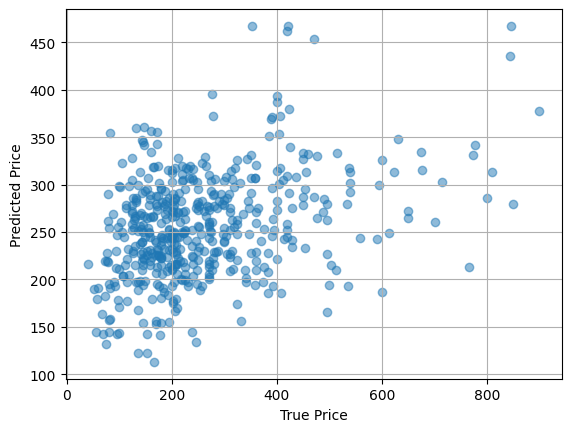

In [17]:
plt.scatter(y_val[y_val < outliers], y_pred, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

## Tuning parameters ##

In [83]:
# Use only train and test set since gridsearch will separate train to train and val subset auto

X_train = np.array([[train_data[i, 0], train_data[i, 1]] for i in range(len(train_subset))])
y_train = np.array([train_data[i, 2] for i in range(len(train_subset))])
X_test = np.array([[test_data[i, 0], test_data[i, 1]] for i in range(len(test_data))])
y_test = test_data[:, 2]

In [84]:
# Set up model and parameters for tuning

param_grid = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1],
    "n_estimators": [100, 300, 500, 1500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

model4tuning = xgb.XGBRegressor(
    tree_method="hist",
    device="cuda",
    booster="gbtree",
    objective="reg:squarederror",
    random_state=42 ## random seed
)

In [20]:
# tuning
outliers = 1000

grid_search = GridSearchCV(
    estimator=model4tuning,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  ## negative MSE
    cv=3,  ## 3-fold cross-validation
    verbose=1,
    n_jobs=1
)

grid_search.fit(X_train[y_train < outliers, :], y_train[y_train < outliers])

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster='gbtree',
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device='cuda',
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.0001, 0.001, 0.01, 0.1],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 300, 500, 1500],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [21]:
print("Best parameters:", grid_search.best_params_)
print("Best MSE:", -grid_search.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best MSE: 18187.945234841336


In [22]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test[y_test < outliers])

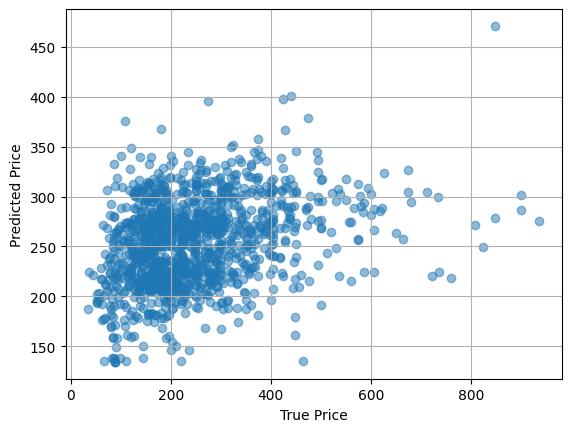

In [27]:
plt.scatter(y_test[y_test < outliers], y_pred, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

In [54]:
# Try unpacking the latitude and longitude

X_train = np.array([train_data[:, 0], train_data[:, 1]])
y_train = train_data[:, 2]
X_test = np.array([test_data[:, 0], test_data[:, 1]])
y_test = test_data[:, 2]

In [55]:
X_train

array([[52.37746   , 52.35813956, 52.4195345 , ..., 52.36526784,
        52.36991   , 52.3553483 ],
       [ 4.83598   ,  4.85167388,  4.89846896, ...,  4.87223363,
         4.88717   ,  4.9276679 ]])

In [60]:
param_grid = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1],
    "n_estimators": [100, 300, 500, 1500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

model4tuning = xgb.XGBRegressor(
    tree_method="hist",
    device="cuda",
    booster="gbtree",
    objective="reg:squarederror",
    random_state=42 ## random seed
)

In [63]:
outliers = 1000

grid_search = GridSearchCV(
    estimator=model4tuning,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  ## negative MSE
    cv=3,  ## 3-fold cross-validation
    verbose=1,
    n_jobs=1
)

grid_search.fit(X_train[:, y_train < outliers].T, y_train[y_train < outliers])

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster='gbtree',
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device='cuda',
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.0001, 0.001, 0.01, 0.1],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 300, 500, 1500],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [64]:
print("Best parameters:", grid_search.best_params_)
print("Best MSE:", -grid_search.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best MSE: 18095.49824853533


In [67]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test[:, y_test < outliers].T)

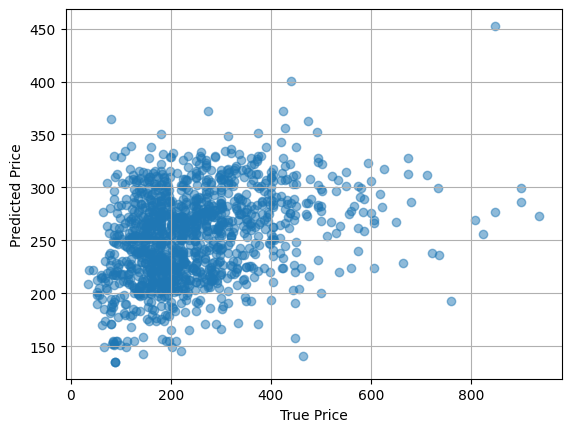

In [68]:
plt.scatter(y_test[y_test < outliers], y_pred, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

In [91]:
X_train = np.array([[train_data[i, 0], train_data[i, 1]] for i in range(len(train_subset))])
y_train = np.array([train_data[i, 2] for i in range(len(train_subset))])
X_test = np.array([[test_data[i, 0], test_data[i, 1]] for i in range(len(test_data))])
y_test = test_data[:, 2]

In [92]:
# add 1 more feature for training set

from sklearn.cluster import KMeans

In [99]:
kmeans = KMeans(n_clusters=10, random_state=42)
cl_train = np.array(kmeans.fit_predict(X_train))
cl_test = np.array(kmeans.fit_predict(X_test))

In [100]:
X_train_cl = np.hstack([X_train, cl_train.reshape(-1, 1)])
X_test_cl = np.hstack([X_test, cl_test.reshape(-1, 1)])

In [95]:
param_grid = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1],
    "n_estimators": [100, 300, 500, 1500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

model4tuning = xgb.XGBRegressor(
    tree_method="hist",
    device="cuda",
    booster="gbtree",
    objective="reg:squarederror",
    random_state=42 ## random seed
)

In [96]:
outliers = 1000

grid_search = GridSearchCV(
    estimator=model4tuning,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  ## negative MSE
    cv=3,  ## 3-fold cross-validation
    verbose=1,
    n_jobs=1
)

grid_search.fit(X_train_cl[y_train < outliers], y_train[y_train < outliers])

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster='gbtree',
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device='cuda',
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.0001, 0.001, 0.01, 0.1],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 300, 500, 1500],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [97]:
print("Best parameters:", grid_search.best_params_)
print("Best MSE:", -grid_search.best_score_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.001, 'max_depth': 6, 'n_estimators': 1500, 'subsample': 0.8}
Best MSE: 18160.586317367022


In [101]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_cl[y_test < outliers])

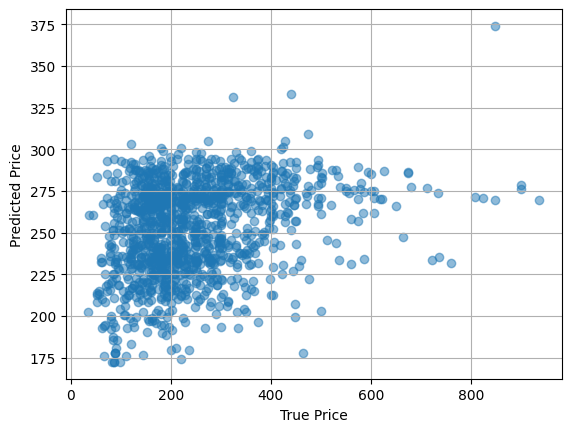

In [102]:
plt.scatter(y_test[y_test < outliers], y_pred, alpha = 0.5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

## Nothing seems to work, trying neuro network model ##

In [184]:
bsize = 64
epochs = 50

train_data = pd.read_csv("train_listings.csv")[["latitude", "longitude", "price"]]
test_data = pd.read_csv("test_listings.csv")[["latitude", "longitude", "price"]]
train_data["price"] = pd.to_numeric(train_data["price"].replace('[\$,]', '', regex=True))  ## get rid of $ sign
test_data["price"] = pd.to_numeric(test_data["price"].replace('[\$,]', '', regex=True))
train_data = train_data.values
test_data = test_data.values

X_train = np.array([[train_data[i][0], train_data[i][1]] for i in range(len(train_data))])
y_train = np.array([train_data[i][2] for i in range(len(train_data))])
X_test = np.array([[test_data[i, 0], test_data[i, 1]] for i in range(len(test_data))])
y_test = test_data[:, 2]
X_test = X_test[y_test < outliers]
y_test = y_test[y_test < outliers]

# Normalize features
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_norm = (X_train - X_mean) / X_std

# Split
X_train, X_val, y_train, y_val = train_test_split(X_norm[y_train < outliers], y_train[y_train < outliers], test_size=0.1, random_state=42)

# Change to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# Dataloader
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_ds, batch_size=bsize, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=bsize, shuffle=True)

In [185]:
# Model MLP
class PriceNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [186]:
lr = 0.001
input_dim = X_train.shape[1]
output_dim = 1

model_MLP = PriceNet(input_dim, output_dim).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model_MLP.parameters(), lr = lr)

In [187]:
def train(dataloader, optimizer, model, loss_function, device):
    losses = []
    model.train()
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        #forward
        y_pred = model(x_batch)
        loss = loss_function(y_pred, y_batch)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return np.mean(losses)

def val(dataloader, model, loss_function, device):
    losses = []
    model.eval()
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        with torch.no_grad():
            val_pred = model(x_batch)
            loss = loss_function(val_pred, y_batch).item()

        losses.append(loss)

    return np.mean(losses)

def run_training(model, optimizer, loss_function, train_dataloader, val_dataloader, num_epochs, device):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        train_loss = train(train_dataloader, optimizer, model, loss_function, device)
        val_loss = val(val_dataloader, model, loss_function, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return train_losses, val_losses

In [188]:
train_loss, val_loss = run_training(model_MLP, optimizer, loss_function, train_loader, val_loader, epochs, device)

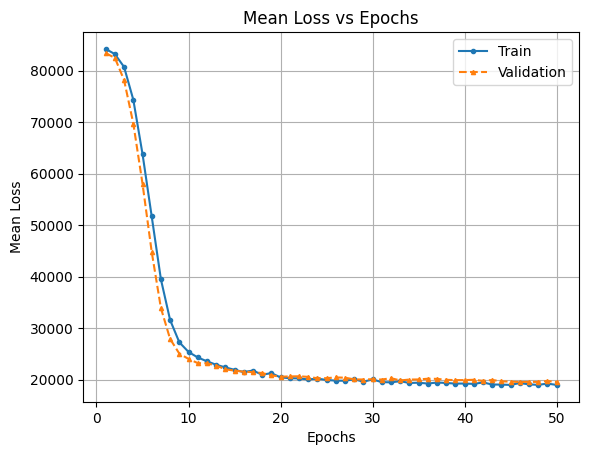

In [189]:
plt.plot(range(1, epochs + 1), train_loss, marker = "o", ms = 3)
plt.plot(range(1, epochs + 1), val_loss, marker = "^", ms = 3, ls = "--")
plt.xlabel("Epochs")
plt.ylabel("Mean Loss")
plt.legend(["Train", "Validation"])
plt.title("Mean Loss vs Epochs")
plt.grid()

In [190]:
np.sqrt(train_loss[-1])

np.float64(137.64936099890437)

The MSE is still quite large

In [198]:
df = pd.read_csv("train_listings.csv")
test1 = df['neighbourhood'].astype('category').cat.codes.values
len(test1[test1 == -1])

2550

In [1]:
df[["neighbourhood", "beds"]]

NameError: name 'df' is not defined